In [1]:
import duckdb
import pandas as pd

con = duckdb.connect("../view/recon_dbt.duckdb", read_only=True)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Сырые файлы

- `payment_engine_log.csv` — лог платёжного движка, источник истины, все провайдеры
- `paypal_us_activity_20260601_20260703.csv` — выписка PayPal US
- `paypal_eu_activity_20260601_20260703.csv` — выписка PayPal EU (`;`, cp1252)
- `adyen_payment_accounting_20260601_20260703.csv` — отчёт Adyen payment accounting
- `dlocal_transactions_20260601_20260703.csv` — экспорт транзакций dLocal
- `google_play_earnings_202606.csv` — отчёт Google Play за июнь
- `google_play_earnings_202607_partial.csv` — отчёт Google Play, 1–3 июля
- `fx_rates.csv` — дневные курсы к USD
- `fee_schedule.csv` — контрактные комиссии провайдеров

In [2]:
con.sql("""
    select table_schema, table_name
    from information_schema.tables
    order by 1, 2
""").df()

,table_schema,table_name
0,analysis,profile_duplicates
1,analysis,profile_summary
2,analysis,profile_values
3,intermediate,int_recon_adyen
4,intermediate,int_recon_dlocal
5,intermediate,int_recon_google_play
6,intermediate,int_recon_paypal_eu
7,intermediate,int_recon_paypal_us
8,marts,fee_summary
9,marts,recon_pairs


In [3]:
def describe_cols(df, max_unique=20):
    for c in df.columns:
        s = df[c]
        line = f"{c:<18} {str(s.dtype):<15} nulls {s.isna().sum():>5}  unique {s.nunique():>5}  "
        if s.nunique() <= max_unique:
            line += str(s.value_counts(dropna=False).to_dict())
        else:
            line += "e.g. " + ", ".join(map(str, s.dropna().head(3)))
        print(line)

## Логи движка

In [4]:
log = con.sql("select * from staging.stg_payment_engine_log").df()
print(log.shape)
log.head()

(7988, 16)


,txn_id,order_id,operation_type,status,psp,psp_reference,sku,country,currency,amount_local,fx_rate_applied,fx_date_applied,amount_usd,signed_amount_usd,created_at_utc,captured_at_utc
0,TXN-107955,ORD-507781,SALE,settled,dlocal,DL-90001309,sub_monthly,MX,MXN,129.00,0.055082,2026-05-29,7.11,7.11,2026-05-31 23:59:50,2026-06-01 00:05:00
1,TXN-100884,ORD-500884,SALE,settled,paypal_us,7FTLSR4XAT5TKVLKF,sub_monthly,US,USD,9.99,1.000000,2026-06-01,9.99,9.99,2026-06-01 07:03:11,2026-06-01 07:12:11
2,TXN-106445,ORD-506445,SALE,settled,dlocal,DL-90000750,sub_monthly,CO,COP,29900.00,0.000251,2026-06-01,7.50,7.50,2026-06-01 07:11:11,2026-06-01 08:27:11
3,TXN-106099,ORD-506099,SALE,settled,dlocal,DL-90000404,sub_monthly,MX,MXN,129.00,0.055014,2026-06-01,7.10,7.10,2026-06-01 07:11:24,2026-06-01 08:17:24
4,TXN-105905,ORD-505905,SALE,settled,dlocal,DL-90000210,sub_quarterly,BR,BRL,89.90,0.184519,2026-06-01,16.59,16.59,2026-06-01 07:12:27,2026-06-01 08:53:27


In [5]:
describe_cols(log)

txn_id             str             nulls     0  unique  7988  e.g. TXN-107955, TXN-100884, TXN-106445
order_id           str             nulls     0  unique  7813  e.g. ORD-507781, ORD-500884, ORD-506445
operation_type     str             nulls     0  unique     3  {'SALE': 7813, 'REFUND': 173, 'CHARGEBACK': 2}
status             str             nulls     0  unique     3  {'settled': 7425, 'declined': 562, 'pending': 1}
psp                str             nulls     0  unique     5  {'paypal_us': 2166, 'paypal_eu': 1891, 'adyen': 1792, 'dlocal': 1319, 'google_play': 820}
psp_reference      str             nulls   820  unique  7168  e.g. DL-90001309, 7FTLSR4XAT5TKVLKF, DL-90000750
sku                str             nulls     0  unique     4  {'sub_monthly': 4476, 'sub_quarterly': 1567, 'sub_annual': 1166, 'coach_addon': 779}
country            str             nulls     0  unique    12  {'US': 2841, 'DE': 1337, 'FR': 752, 'BR': 725, 'GB': 708, 'MX': 403, 'NL': 366, 'ES': 273, 'IT': 186, 'C

In [6]:
con.sql("""
    select psp,
           count(*) filter (where operation_type = 'SALE') as sales,
           count(*) filter (where operation_type <> 'SALE') as reversals,
           sum(signed_amount_usd) as net_usd,
           sum(sum(signed_amount_usd)) over() as sum_net_usd,
           100 * sum(signed_amount_usd) / sum(sum(signed_amount_usd)) over() as share_usd
    from staging.stg_payment_engine_log
    where status = 'settled'
      and captured_at_utc >= '2026-06-01' and captured_at_utc < '2026-07-01'
    group by 1 order by 6 desc
""").df().round(2).to_csv("../out/engine_june_by_psp.tsv", sep="\t", index=False)

In [7]:
sales = con.sql("""
    select psp, currency, sku, amount_local::double as amount_local, amount_usd::double as amount_usd
    from staging.stg_payment_engine_log
    where status = 'settled' and operation_type = 'SALE'
      and captured_at_utc >= '2026-06-01' and captured_at_utc < '2026-07-01'
""").df()

print(sales.groupby("psp")["amount_usd"].describe().round(2))

              count    mean      std   min    25%    50%    75%        max
psp                                                                       
adyen        1577.0   21.14    19.36  4.99  10.79  10.91  27.16      71.63
dlocal       1152.0  187.37  5889.26  2.15   6.42   7.14  16.61  199900.00
google_play   766.0   19.49    18.14  3.08   9.99  10.86  24.99      71.40
paypal_eu    1660.0   22.18    19.84  5.39  10.86  10.94  27.23      71.63
paypal_us    1893.0   19.39    17.59  4.99   9.99   9.99  24.99      59.99


In [8]:
(sales.groupby("psp")["amount_usd"].describe().round(2)
      .reset_index()
      .to_csv("../out/engine_june_sales_amount_usd_by_psp.tsv", sep="\t", index=False))

/var/folders/31/9gczcyrx1_j7m818mncf3rpm0000gn/T/ipykernel_49195/2425249548.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, tick_labels=order, vert=False, widths=0.5,


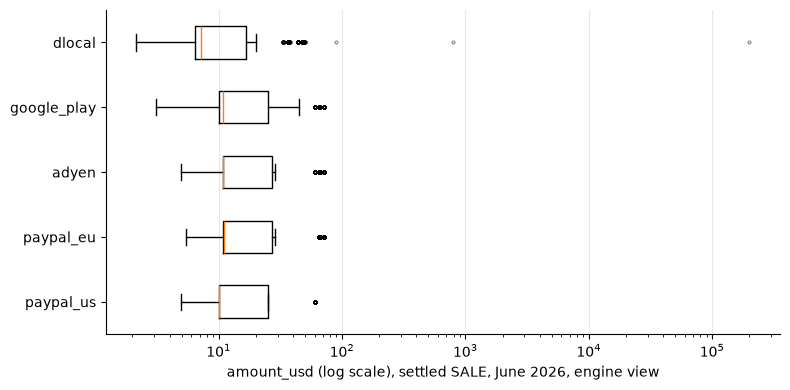

In [9]:
import matplotlib.pyplot as plt

order = ["paypal_us", "paypal_eu", "adyen", "google_play", "dlocal"]
data = [sales.loc[sales["psp"] == p, "amount_usd"] for p in order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, tick_labels=order, vert=False, widths=0.5,
           flierprops=dict(marker=".", markersize=4, alpha=0.4))
ax.set_xscale("log")
ax.set_xlabel("amount_usd (log scale), settled SALE, June 2026, engine view")
ax.grid(axis="x", alpha=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## Сверка с paypal us

In [10]:
paypal_us = con.sql("select * from staging.stg_paypal_us_activity").df()
print(paypal_us.shape)
paypal_us.head(2)

(2167, 13)


,transaction_id,reference_txn_id,invoice_id,txn_type,status,currency,gross,fee,net,txn_at_utc,time_zone,customer_name,dup_rank
0,0CWV1YBTAVLUL4Q2Q,NaN,ORD-500412,Website Payment,Completed,USD,24.99,-1.36,23.63,2026-06-15 18:53:12,GMT,Drew Bennett,1
1,0NQQQKSLURT8L1EZ6,NaN,ORD-502019,Website Payment,Completed,USD,59.99,-2.58,57.41,2026-06-25 08:38:34,GMT,Taylor Brooks,1


In [11]:
describe_cols(paypal_us)

transaction_id     str             nulls     0  unique  2166  e.g. 0CWV1YBTAVLUL4Q2Q, 0NQQQKSLURT8L1EZ6, 0P2VPDDG1P7HNV1T3
reference_txn_id   str             nulls  2110  unique    57  e.g. 68RYCUUUDDZSWYEJG, VA42E98MMAWKGHKWK, F5XD9ZP4R3U182EVF
invoice_id         str             nulls     0  unique  2109  e.g. ORD-500412, ORD-502019, ORD-501589
txn_type           str             nulls     0  unique     2  {'Website Payment': 2110, 'Refund': 57}
status             str             nulls     0  unique     3  {'Completed': 1942, 'Denied': 168, 'Refunded': 57}
currency           str             nulls     0  unique     1  {'USD': 2167}
gross              float64         nulls     0  unique    11  {9.99: 1181, 24.99: 417, 59.99: 293, 4.99: 219, -9.99: 20, -5.0: 16, -59.99: 6, -4.99: 5, -30.0: 4, -24.99: 4, -12.5: 2}
fee                float64         nulls     0  unique     5  {-0.84: 1084, -1.36: 380, -2.58: 271, 0.0: 225, -0.66: 207}
net                float64         nulls     0  unique  

In [12]:
con.sql("""
    select
        count(*) filter (where txn_type = 'Website Payment') as sales,
        count(*) filter (where txn_type = 'Refund')          as reversals,
        sum(gross)                                          as net_usd
    from staging.stg_paypal_us_activity
    where status <> 'Denied'
      and txn_at_utc >= '2026-06-01' and txn_at_utc < '2026-07-01'
""").df()

,sales,reversals,net_usd
0,1895,39,36081.29


In [13]:
recon_pu = con.sql("""
with engine as (
    select psp_reference, operation_type, status,
           case when status = 'settled' then signed_amount_usd else 0 end as engine_usd
    from staging.stg_payment_engine_log
    where psp = 'paypal_us'
      and coalesce(captured_at_utc, created_at_utc) >= '2026-06-01'
      and coalesce(captured_at_utc, created_at_utc) <  '2026-07-01'
),
provider as (
    select transaction_id, txn_type, status as pp_status, dup_rank,
           case when status <> 'Denied' then gross else 0 end as provider_usd
    from staging.stg_paypal_us_activity
    where txn_at_utc >= '2026-06-01' and txn_at_utc < '2026-07-01'
),
pairs as (
    select
        case
            when p.transaction_id is null                                   then 'missing_at_provider'
            when e.psp_reference is null                                    then 'missing_in_engine'
            when p.dup_rank = 2                                             then 'duplicate_row_in_export'
            when e.status = 'settled'  and p.pp_status in ('Completed', 'Refunded') then 'matched'
            when e.status = 'declined' and p.pp_status = 'Denied'           then 'matched_declined'
            else 'status_mismatch'
        end as cause,
        case when p.dup_rank = 2 then 0 else coalesce(e.engine_usd, 0) end as engine_usd,
        coalesce(p.provider_usd, 0)                                          as provider_usd
    from engine e
    full join provider p on p.transaction_id = e.psp_reference
)
select cause, count(*) as rows,
       round(sum(engine_usd), 2)                 as engine_usd,
       round(sum(provider_usd), 2)               as provider_usd,
       round(sum(provider_usd - engine_usd), 2)  as diff_usd
from pairs
group by 1 order by 1
""").df()
recon_pu.to_csv("../out/recon_june_paypal_us_by_cause.tsv", sep="\t", index=False)
recon_pu

,cause,rows,engine_usd,provider_usd,diff_usd
0,duplicate_row_in_export,1,0.00,9.99,9.99
1,matched,1932,36046.31,36046.31,0.00
2,matched_declined,158,0.00,0.00,0.00
3,status_mismatch,1,0.00,24.99,24.99


In [14]:
con.sql("""
    select
        count(*) as settled_rows,
        min(epoch(captured_at_utc - created_at_utc))            as min_s,
        median(epoch(captured_at_utc - created_at_utc))         as median_s,
        quantile_cont(epoch(captured_at_utc - created_at_utc), 0.99) as p99_s,
        max(epoch(captured_at_utc - created_at_utc))            as max_s
    from staging.stg_payment_engine_log
    where psp = 'paypal_us' and status = 'settled' and operation_type = 'SALE'
""").df()

,settled_rows,min_s,median_s,p99_s,max_s
0,1940,290.0,3300.0,6540.0,6600.0


## Сверка с paypal eu

In [15]:
fx = con.sql("select * from raw.raw_fx_rates").df()
print(fx.shape)
fx.head()

(204, 4)


,rate_date,currency,usd_rate,published_at
0,2026-05-25,ARS,0.000839,2026-05-25T16:00:00Z
1,2026-05-25,BRL,0.184871,2026-05-25T16:00:00Z
2,2026-05-25,CLP,0.001060,2026-05-25T16:00:00Z
3,2026-05-25,COP,0.000248,2026-05-25T16:00:00Z
4,2026-05-25,EUR,1.093525,2026-05-25T16:00:00Z


In [16]:
con.sql("""
    select count(*) filter (where provider_type = 'Website Payment')                 as sales,
           count(*) filter (where provider_type in ('Refund', 'Payment Reversal'))   as reversals,
           round(sum(provider_usd), 2)                                               as net_usd
    from intermediate.int_recon_paypal_eu
    where provider_in_period
""").df()

,sales,reversals,net_usd
0,1803,27,36197.37


In [17]:
recon_eu = con.sql("""
    select cause, count(*) as n, round(sum(engine_usd), 2) as engine_usd,
           round(sum(provider_usd), 2) as provider_usd, round(sum(diff_usd), 2) as diff_usd
    from intermediate.int_recon_paypal_eu group by 1 order by 1
""").df()
recon_eu.to_csv("../out/recon_june_paypal_eu_by_cause.tsv", sep="\t", index=False)
recon_eu

,cause,n,engine_usd,provider_usd,diff_usd
0,engine_fx_date_error,1,65.75,65.19,-0.56
1,matched,1681,36224.53,36224.53,0.00
2,matched_declined,146,0.00,0.00,0.00
3,missing_in_engine,2,0.00,-92.35,-92.35
4,provider_date_format,3,32.73,0.00,-32.73


## Сверка с dLocal

In [18]:
con.sql("""
    select
        count(*) filter (where status = 'PAID')                  as sales,
        count(*) filter (where status = 'REFUNDED')              as reversals,
        round(sum(signed_amount_usd)
              filter (where status in ('PAID', 'REFUNDED')), 2)  as net_usd
    from staging.stg_dlocal_transactions
    where txn_at_utc >= '2026-06-01' and txn_at_utc < '2026-07-01'
""").df()

,sales,reversals,net_usd
0,1151,18,14949.48


In [19]:
recon_dl = con.sql("""
    select cause, count(*) as n, round(sum(engine_usd), 2) as engine_usd,
           round(sum(provider_usd), 2) as provider_usd, round(sum(diff_usd), 2) as diff_usd
    from intermediate.int_recon_dlocal group by 1 order by 1
""").df()
recon_dl.to_csv("../out/recon_june_dlocal_by_cause.tsv", sep="\t", index=False)
recon_dl

,cause,n,engine_usd,provider_usd,diff_usd
0,amount_mismatch,1,-11.04,-18.40,-7.36
1,duplicate_row_in_export,1,0.00,7.13,7.13
2,engine_fx_rate_error,3,200788.90,109.46,-200679.44
3,matched,1161,14807.34,14807.34,0.00
4,matched_declined,109,0.00,0.00,0.00
5,missing_at_provider,1,7.42,0.00,-7.42
6,provider_fx_rate,3,43.46,43.95,0.49
7,status_mismatch,1,6.45,0.00,-6.45


## Сверка с Adyen

In [20]:
con.sql("""
    with fx as (
        select * from staging.stg_fx_rates where dup_rank = 1
    ),
    money as (
        select a.record_type, a.signed_gross,
               round(a.signed_gross * case when a.currency = 'USD' then 1 else fx.usd_rate end, 2) as signed_usd
        from staging.stg_adyen_payment_accounting a
        asof left join fx on fx.currency = a.currency and fx.rate_date <= a.event_at_utc::date
        where a.record_type in ('Settled', 'Refunded', 'Chargeback')
          and a.event_at_utc >= '2026-06-01' and a.event_at_utc < '2026-07-01'
    )
    select
        count(*) filter (where record_type = 'Settled')  as sales,
        count(*) filter (where record_type <> 'Settled') as reversals,
        round(sum(signed_usd), 2)                        as net_usd
    from money
""").df()

,sales,reversals,net_usd
0,1576,27,32796.14


In [21]:
recon_ad = con.sql("""
    select cause, count(*) as n, round(sum(engine_usd), 2) as engine_usd,
           round(sum(provider_usd), 2) as provider_usd, round(sum(diff_usd), 2) as diff_usd
    from intermediate.int_recon_adyen group by 1 order by 1
""").df()
recon_ad.to_csv("../out/recon_june_adyen_by_cause.tsv", sep="\t", index=False)
recon_ad

,cause,n,engine_usd,provider_usd,diff_usd
0,amount_mismatch,2,93.79,53.43,-40.36
1,fx_date_lag,1,28.34,28.37,0.03
2,matched,1598,32768.27,32768.27,0.00
3,matched_declined,133,0.00,0.00,0.00
4,missing_in_engine,2,0.00,-53.93,-53.93
5,period_cutoff,1,10.79,0.00,-10.79
6,status_mismatch,1,10.90,0.00,-10.90


In [22]:
con.sql("""
    select merchant_account, currency, count(*) as n,
           round(sum(gross_credit), 2) as gross,
           round(sum(fee), 2) as fee,
           round(sum(fee) / sum(gross_credit) * 100, 2) as fee_pct,
           count(*) filter (where round(fee / gross_credit * 100, 1) <> 2.5) as rows_off_contract
    from staging.stg_adyen_payment_accounting
    where record_type = 'Settled'
      and event_at_utc >= '2026-06-01' and event_at_utc < '2026-07-01'
    group by 1, 2 order by 1, 2
""").df()


,merchant_account,currency,n,gross,fee,fee_pct,rows_off_contract
0,LumoAPP_US,USD,306,6276.94,157.00,2.50,32
1,LumoECOM_EU,EUR,1007,19355.93,483.98,2.50,99
2,LumoECOM_EU,GBP,263,4596.38,114.01,2.48,171


## Сверка с Google Play

In [23]:
con.sql("""
    select
        count(*) filter (where txn_type = 'Charge')         as sales,
        count(*) filter (where txn_type = 'Charge refund')  as reversals,
        round(sum(amount_usd)
              filter (where txn_type in ('Charge', 'Charge refund')), 2) as net_usd
    from staging.stg_google_play_earnings
    where txn_at_utc >= '2026-06-01' and txn_at_utc < '2026-07-01'
""").df()

,sales,reversals,net_usd
0,766,10,14744.63


In [24]:
recon_gp = con.sql("""
    select cause, count(*) as n, round(sum(engine_usd), 2) as engine_usd,
           round(sum(provider_usd), 2) as provider_usd, round(sum(diff_usd), 2) as diff_usd
    from intermediate.int_recon_google_play group by 1 order by 1
""").df()
recon_gp.to_csv("../out/recon_june_google_play_by_cause.tsv", sep="\t", index=False)
recon_gp

,cause,n,engine_usd,provider_usd,diff_usd
0,matched,776,14744.63,14744.63,0.0


## Summary

In [25]:
con.sql("select * from marts.recon_totals").df()

,psp,pair_count,engine_rows,provider_rows,engine_usd,provider_usd,total_diff,matched_usd,explained_usd,unexplained_usd,residual
0,adyen,1738.0,1736.0,1738.0,32912.09,32796.14,-115.95,0.0,-115.95,0.0,0.0
1,dlocal,1280.0,1280.0,1279.0,215642.53,14949.48,-200693.05,0.0,-200693.05,0.0,0.0
2,google_play,776.0,776.0,776.0,14744.63,14744.63,0.00,0.0,0.00,0.0,0.0
3,paypal_eu,1833.0,1831.0,1833.0,36323.01,36197.37,-125.64,0.0,-125.64,0.0,0.0
4,paypal_us,2092.0,2092.0,2092.0,36046.31,36081.29,34.98,0.0,34.98,0.0,0.0
5,total,7719.0,7715.0,7718.0,335668.57,134768.91,-200899.66,0.0,-200899.66,0.0,0.0


In [26]:
totals = con.sql("""
    select psp,
           engine_usd    as "движок",
           provider_usd  as "провайдер",
           total_diff    as "разница",
           explained_usd as "explained",
           residual      as "остаток"
    from marts.recon_totals
""").df()
totals.to_csv("../out/recon_june_totals.tsv", sep="\t", index=False)
totals


,psp,движок,провайдер,разница,explained,остаток
0,adyen,32912.09,32796.14,-115.95,-115.95,0.0
1,dlocal,215642.53,14949.48,-200693.05,-200693.05,0.0
2,google_play,14744.63,14744.63,0.00,0.00,0.0
3,paypal_eu,36323.01,36197.37,-125.64,-125.64,0.0
4,paypal_us,36046.31,36081.29,34.98,34.98,0.0
5,total,335668.57,134768.91,-200899.66,-200899.66,0.0


In [27]:
totals = con.sql("select * from marts.recon_totals").df()
totals.to_csv("../out/recon_june_totals.tsv", sep="\t", index=False)
totals

summary = con.sql("""
    select psp, cause, row_count, abs_usd, signed_usd, share_pct, share_in_psp_pct
    from marts.recon_summary
    order by psp, abs_usd desc
""").df()
summary.to_csv("../out/recon_june_summary_by_cause.tsv", sep="\t", index=False)
summary

,psp,cause,row_count,abs_usd,signed_usd,share_pct,share_in_psp_pct
0,adyen,missing_in_engine,2,75.65,-53.93,0.04,54.93
1,adyen,amount_mismatch,2,40.36,-40.36,0.02,29.30
2,adyen,status_mismatch,1,10.90,-10.90,0.01,7.91
3,adyen,period_cutoff,1,10.79,-10.79,0.01,7.83
4,adyen,fx_date_lag,1,0.03,0.03,0.00,0.02
5,adyen,matched,1598,0.00,0.00,0.00,0.00
6,adyen,matched_declined,133,0.00,0.00,0.00,0.00
7,dlocal,engine_fx_rate_error,3,200679.44,-200679.44,99.84,99.99
8,dlocal,missing_at_provider,1,7.42,-7.42,0.00,0.00
9,dlocal,amount_mismatch,1,7.36,-7.36,0.00,0.00


In [28]:
by_psp = con.sql("select * from marts.recon_summary_by_psp").df()
by_psp.to_csv("../out/recon_june_summary_by_psp.tsv", sep="\t", index=False)
by_psp

,psp,row_count,discrepancy_rows,abs_usd,signed_usd,share_pct
0,dlocal,1280.0,10.0,200708.29,-200693.05,99.85
1,adyen,1738.0,7.0,137.73,-115.95,0.07
2,paypal_eu,1833.0,6.0,125.64,-125.64,0.06
3,paypal_us,2092.0,2.0,34.98,34.98,0.02
4,google_play,776.0,0.0,0.00,0.00,0.00
5,total,7719.0,25.0,201006.64,-200899.66,100.00
